<a href="https://colab.research.google.com/github/pegumzs/MVP_trab3/blob/main/Projeto_SSD_MVP_Triagem_de_Mensagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de suporte à decisão para triagem de mensagens suspeitas

MVP da disciplina Sistemas de Suporte à Decisão
Departamento de Engenharia de Produção, Universidade de Brasília
Professor: André Luiz Marques Serrano

Aluno(a): Pedro Augusto - 180114425

O notebook segue as etapas pedidas para o MVP: objetivo, coleta, modelagem, qualidade dos dados, transformação e carga, análise, ética e autoavaliação.

## 1. Objetivo

### Problema

Golpes por mensagem de texto, conhecidos como smishing, tentam convencer a pessoa a transferir dinheiro ou passar dados. Em uma empresa, cada golpe que chega a um funcionário é um risco, e revisar todas as mensagens à mão não é viável.

O problema deste MVP é decidir, com pouca intervenção humana, o que fazer com cada mensagem recebida: liberar, encaminhar para revisão da equipe de TI ou bloquear.

### Hipótese

Um classificador simples, treinado com mensagens já rotuladas, consegue bloquear pelo menos 90% dos golpes, bloqueando no máximo 5% das mensagens legítimas e mandando no máximo 10% das mensagens para revisão humana. As três metas são medidas no conjunto de teste, na seção 7.3.

### Perguntas de negócio

| # | Pergunta | Decisão que a resposta apoia |
|---|---|---|
| P1 | Que características do texto diferenciam os golpes das mensagens legítimas? | Quais sinais usar para orientar os funcionários e criar regras de filtro |
| P2 | Entre a árvore de decisão e o Naive Bayes, qual modelo deixa passar menos golpes, e quantos alarmes falsos cada um gera? | Qual modelo adotar |
| P3 | Com a regra de decisão proposta, quantos golpes são bloqueados, quantas mensagens vão para revisão e quantas legítimas são bloqueadas? | Se o sistema pode ser adotado e quanto trabalho de revisão ele gera para a TI |
| P4 | Como a escolha do limite de bloqueio muda o número de golpes não bloqueados e de legítimas bloqueadas? | Qual limite a empresa deve usar |
| P5 | O modelo treinado com mensagens de Moçambique reconhece golpes comuns no Brasil? | Se o modelo pode ser usado no Brasil sem novo treinamento |

## 2. Bibliotecas e pasta dos dados

Todas as bibliotecas já vêm instaladas no Google Colab.

Os dados são guardados em três pastas, uma para cada camada: bronze (dado bruto), silver (dado tratado) e gold (resultados). Por padrão as pastas ficam no próprio Colab. Para guardar no Google Drive, troque `usar_google_drive` para `True` e autorize o acesso quando o Colab pedir.

In [ ]:
# Manipulação de dados e gráficos
import os
import urllib.request
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de palavras comuns do português
import nltk
from nltk.corpus import stopwords

# Modelos e métricas do scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# Onde as camadas de dados são salvas
usar_google_drive = False

if usar_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    pasta_dados = '/content/drive/MyDrive/mvp_smishing'
else:
    pasta_dados = '/content/mvp_smishing'

for camada in ['bronze', 'silver', 'gold']:
    os.makedirs(pasta_dados + '/' + camada, exist_ok=True)

print('Dados salvos em:', pasta_dados)

Dados salvos em: /content/mvp_smishing


## 3. Coleta

Procurei uma base pública de mensagens de golpe em português, com rótulo indicando se cada mensagem é golpe ou não. Não encontrei uma base brasileira assim. A MOZ-Smishing foi a opção mais próxima: tem mensagens reais em português, rotuladas, e foi publicada junto com um artigo científico. As mensagens vêm de Moçambique, e essa diferença é discutida na P5.

| Item | Valor |
|---|---|
| Nome | MOZ-Smishing |
| Origem | https://huggingface.co/datasets/MOZNLP/MOZ-Smishing |
| Licença | CreativeML OpenRAIL-M, conforme a página da base |
| Formato original | Um arquivo CSV (`test.csv`) com as colunas `id`, `source`, `text` e `label` |
| Técnica de coleta | Download direto do arquivo, sem web scraping |
| Volume esperado | 2.561 mensagens: 2.009 legítimas e 552 golpes |

A data da coleta, o tamanho do arquivo e o número de linhas são registrados pela célula abaixo.

Referência: ALI, F. D. M. A.; SAIDE, S. M.; SOUSA-SILVA, R.; LOPES CARDOSO, H. MOZ-Smishing: a benchmark dataset for detecting mobile money frauds. In: WORKSHOP ON AFRICAN NATURAL LANGUAGE PROCESSING (AfricaNLP 2025), 6., 2025, Viena. Proceedings [...]. Viena: Association for Computational Linguistics, 2025.

In [ ]:
# Download do arquivo original para a camada bronze
url = 'https://huggingface.co/datasets/MOZNLP/MOZ-Smishing/resolve/main/test.csv'
arquivo_bronze = pasta_dados + '/bronze/moz_smishing.csv'
urllib.request.urlretrieve(url, arquivo_bronze)

# Leitura sem alterar nenhum valor
bronze = pd.read_csv(arquivo_bronze, dtype=str, keep_default_na=False)

# Registro da coleta
data_coleta = datetime.now().strftime('%d/%m/%Y')
print('Data da coleta:', data_coleta)
print('Tamanho do arquivo:', round(os.path.getsize(arquivo_bronze) / 1024, 1), 'kB')
print('Linhas:', len(bronze))
print('Colunas:', list(bronze.columns))

Data da coleta: 28/09/2026
Tamanho do arquivo: 315.3 kB
Linhas: 2561
Colunas: ['id', 'source', 'text', 'label']


## 4. Modelagem e catálogo de dados

O modelo segue a organização de Data Lake, com uma tabela plana por conceito em cada camada. O esquema estrela não foi usado porque o projeto tem um único conceito central, a mensagem, e nenhum atributo que justifique uma tabela de dimensão separada.

| Camada | Tabela | Uma linha representa |
|---|---|---|
| bronze | `moz_smishing.csv` | Uma linha do arquivo original, sem alteração |
| silver | `mensagens.csv` | Uma mensagem única, tratada e anonimizada |
| gold | `sinais_por_classe.csv` | Uma classe (golpe ou legítima) |
| gold | `predicoes.csv` | Uma mensagem do conjunto de teste, com risco e ação recomendada |
| gold | `simulacao_limites.csv` | Um valor de limite de bloqueio |

Linhagem: arquivo do Hugging Face → bronze → regras R1 a R8 (seção 6) → silver → análises da seção 7 → gold.

### Catálogo: bronze

| Atributo | Tipo | Descrição | Domínio | Obrigatório |
|---|---|---|---|---|
| `id` | texto | Identificador da mensagem na fonte | Formato `número_0` (legítima) ou `número_1` (golpe), único | Sim |
| `source` | categórico | Canal de origem | Categorias listadas na seção 5 | Sim |
| `text` | texto | Texto original, com dados pessoais | De 5 a 477 caracteres, segundo a fonte | Sim |
| `label` | categórico | Rótulo da fonte | `Legitimate` ou `Smishing` | Sim |

### Catálogo: silver

| Atributo | Tipo | Descrição | Domínio | Obrigatório | Linhagem |
|---|---|---|---|---|---|
| `id_mensagem` | texto | Identificador da mensagem | Igual ao `id`, único | Sim | `id` (R1) |
| `fonte` | categórico | Canal de origem | Igual ao `source` | Sim | `source` (R1) |
| `texto` | texto | Mensagem com espaços padronizados e números de 7 ou mais dígitos trocados por `NUM_OCULTO` | Pelo menos 1 caractere, sem sequências de 7 ou mais dígitos | Sim | `text` (R3 e R8) |
| `classe` | categórico | Rótulo da mensagem | `golpe` ou `legítima` | Sim | `label` (R2) |
| `tamanho_caracteres` | inteiro | Caracteres da mensagem antes da anonimização | De 1 a 477 | Sim | `text` (R7) |
| `qtd_palavras` | inteiro | Palavras da mensagem antes da anonimização | Maior que zero | Sim | `text` (R7) |
| `tem_numero` | booleano | Se a mensagem tinha 7 ou mais dígitos seguidos (telefone ou conta) | Verdadeiro ou falso | Sim | `text` (R7) |
| `tem_link` | booleano | Se a mensagem tem `http`, `www.` ou `bit.ly` | Verdadeiro ou falso | Sim | `text` (R7) |
| `menciona_nome` | booleano | Se a mensagem contém a palavra "nome" | Verdadeiro ou falso | Sim | `text` (R7) |

### Catálogo: gold

| Tabela | Atributo | Tipo | Domínio |
|---|---|---|---|
| `sinais_por_classe` | `classe` | categórico | `golpe` ou `legítima` |
| `sinais_por_classe` | `mensagens` | inteiro | Maior que zero |
| `sinais_por_classe` | `media_caracteres`, `media_palavras` | decimal | Maior que zero |
| `sinais_por_classe` | `pct_com_numero`, `pct_com_link`, `pct_menciona_nome` | decimal | De 0 a 100 |
| `predicoes` | `id_mensagem` | texto | Ids do conjunto de teste |
| `predicoes` | `classe_real`, `previsao_arvore`, `previsao_nb` | categórico | `golpe` ou `legítima` |
| `predicoes` | `risco_golpe` | decimal | De 0 a 1 |
| `predicoes` | `acao_recomendada` | categórico | `LIBERAR`, `REVISAR` ou `BLOQUEAR` |
| `simulacao_limites` | `limite_bloqueio` | decimal | De 0,50 a 0,99 |
| `simulacao_limites` | `golpes_bloqueados`, `golpes_nao_bloqueados`, `legitimas_bloqueadas` | inteiro | De 0 ao total da classe no teste |

## 5. Qualidade dos dados

A análise é feita sobre a bronze, antes de qualquer tratamento. Os textos das mensagens não são exibidos, porque contêm nomes e números de telefone.

In [ ]:
# Completude e unicidade de cada atributo
resumo = []
for coluna in ['id', 'source', 'text', 'label']:
    vazios = (bronze[coluna].str.strip() == '').sum()
    distintos = bronze[coluna].nunique()
    repetidos = bronze[coluna].duplicated().sum()
    resumo.append({'atributo': coluna, 'vazios': vazios, 'valores_distintos': distintos, 'valores_repetidos': repetidos})

display(pd.DataFrame(resumo))

,atributo,vazios,valores_distintos,valores_repetidos
0,id,0,2561,0
1,source,0,2,2559
2,text,0,2560,1
3,label,0,2,2559


In [ ]:
# Conformidade: valores de label e source, e formato do id
print(bronze['label'].value_counts())
print()
print(bronze['source'].value_counts())
print()
print('Ids fora do formato número_0 ou número_1:', (~bronze['id'].str.match('^[0-9]+_[01]$')).sum())

label
Legitimate    2009
Smishing       552
Name: count, dtype: int64

source
sms    2161
fb      400
Name: count, dtype: int64

Ids fora do formato número_0 ou número_1: 0


In [ ]:
# Consistência: o final do id deve bater com o rótulo
print(pd.crosstab(bronze['id'].str[-2:], bronze['label']))

# Consistência: o mesmo texto não deveria ter rótulos diferentes
rotulos_por_texto = bronze.groupby('text')['label'].nunique()
print()
print('Textos que aparecem com os dois rótulos:', (rotulos_por_texto > 1).sum())
print('Linhas com texto e rótulo repetidos:', bronze.duplicated(subset=['text', 'label']).sum())

label  Legitimate  Smishing
id                         
_0           2009         0
_1              0       552

Textos que aparecem com os dois rótulos: 1
Linhas com texto e rótulo repetidos: 0


In [ ]:
# Acurácia e formatação: tamanho das mensagens, quebras de linha e espaços repetidos
tamanho = bronze['text'].str.len()
print(tamanho.groupby(bronze['label']).describe().round(1))
print()
print('Mensagens com menos de 10 caracteres:', (tamanho < 10).sum())
print('Mensagens com quebra de linha:', bronze['text'].str.contains('\n').sum())
print('Mensagens com espaços repetidos:', bronze['text'].str.contains('  ').sum())

# Dados pessoais: sequências de 7 ou mais dígitos (telefones e contas)
print('Mensagens com número de telefone ou conta:', bronze['text'].str.contains('[0-9]{7,}').sum())

             count   mean   std   min   25%   50%    75%    max
label                                                          
Legitimate  2009.0  104.6  59.8   5.0  53.0  96.0  152.0  477.0
Smishing     552.0   95.8  23.0  44.0  79.0  93.0  111.0  185.0

Mensagens com menos de 10 caracteres: 5
Mensagens com quebra de linha: 126
Mensagens com espaços repetidos: 436
Mensagens com número de telefone ou conta: 1007


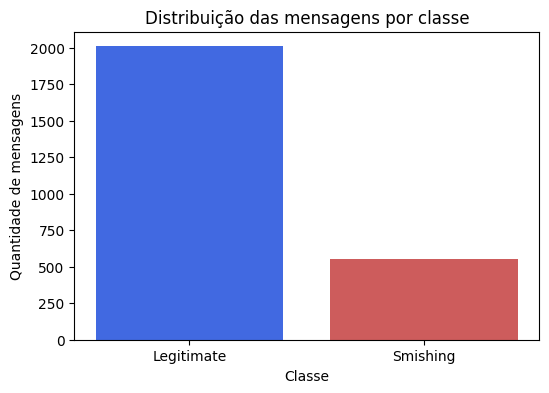

In [ ]:
# Quantidade de mensagens em cada classe
contagem = bronze['label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(contagem.index, contagem.values, color=['royalblue', 'indianred'])
plt.title('Distribuição das mensagens por classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade de mensagens')
plt.show()

Como ler este diagnóstico e o que é feito com cada problema:

- Textos vazios ou rótulos fora do domínio são descartados (R4).
- Textos com os dois rótulos são descartados, porque não dá para saber qual está certo (R5).
- Mensagens repetidas ficam uma vez só, para que a mesma mensagem não caia no treino e no teste ao mesmo tempo (R6).
- Quebras de linha e espaços repetidos são padronizados (R3).
- Números de telefone e de conta são anonimizados (R8).

Mensagens curtas são mantidas, porque são plausíveis em SMS. A base é um retrato fixo, publicado em 2025, e não recebe atualizações.

A base também é desbalanceada, com quase quatro mensagens legítimas para cada golpe. Isso reflete a prática e não é um erro, mas explica por que a acurácia não é a métrica principal: um modelo que chamasse tudo de legítimo acertaria cerca de 78% das mensagens sem pegar nenhum golpe.

## 6. Transformação e carga

As regras são aplicadas na ordem abaixo, e o resultado é gravado na camada silver.

| Regra | O que faz |
|---|---|
| R1 | Renomeia as colunas para português |
| R2 | Traduz os rótulos: `Smishing` vira `golpe` e `Legitimate` vira `legítima` |
| R3 | Troca quebras de linha e espaços repetidos por um espaço e remove espaços nas pontas |
| R4 | Descarta textos vazios e classes fora do domínio |
| R5 | Descarta textos que aparecem com as duas classes |
| R6 | Mantém uma linha por texto, a de menor id |
| R7 | Cria os atributos derivados, antes da anonimização |
| R8 | Troca toda sequência de 7 ou mais dígitos por `NUM_OCULTO` |

In [ ]:
silver = bronze.copy()

# R1: nomes das colunas em português
silver = silver.rename(columns={'id': 'id_mensagem', 'source': 'fonte', 'text': 'texto', 'label': 'classe'})

# R2: rótulos em português (valores fora do domínio ficam vazios)
silver['classe'] = silver['classe'].map({'Smishing': 'golpe', 'Legitimate': 'legítima'})

# R3: padroniza espaços e quebras de linha
silver['texto'] = silver['texto'].str.replace(r'\s+', ' ', regex=True).str.strip()

# R4: descarta textos vazios e classes inválidas
silver = silver[(silver['texto'] != '') & (silver['classe'].notna())]

# R5: descarta textos que aparecem com as duas classes
classes_por_texto = silver.groupby('texto')['classe'].nunique()
textos_contraditorios = classes_por_texto[classes_por_texto > 1].index
silver = silver[~silver['texto'].isin(textos_contraditorios)]

# R6: uma linha por texto, a de menor id
silver = silver.sort_values('id_mensagem')
silver = silver.drop_duplicates(subset='texto', keep='first')

# R7: atributos derivados
silver['tamanho_caracteres'] = silver['texto'].str.len()
silver['qtd_palavras'] = silver['texto'].str.split().str.len()
silver['tem_numero'] = silver['texto'].str.contains('[0-9]{7,}')
silver['tem_link'] = silver['texto'].str.lower().str.contains('http|www[.]|bit[.]ly')
silver['menciona_nome'] = silver['texto'].str.lower().str.contains('nome')

# R8: anonimização de telefones e contas
silver['texto'] = silver['texto'].str.replace('[0-9]{7,}', 'NUM_OCULTO', regex=True)

# Carga na camada silver
silver = silver.reset_index(drop=True)
silver.to_csv(pasta_dados + '/silver/mensagens.csv', index=False)

In [ ]:
# Conciliação entre bronze e silver
print('Linhas na bronze:', len(bronze))
print('Linhas na silver:', len(silver))
print('Linhas removidas pelas regras R4, R5 e R6:', len(bronze) - len(silver))
print()
print(silver['classe'].value_counts())

# Conferências: anonimização e faixa dos atributos numéricos
print()
print('Textos da silver com número exposto:', silver['texto'].str.contains('[0-9]{7,}').sum())
print('Caracteres: mínimo', silver['tamanho_caracteres'].min(), '| máximo', silver['tamanho_caracteres'].max())
print('Palavras: mínimo', silver['qtd_palavras'].min(), '| máximo', silver['qtd_palavras'].max())

Linhas na bronze: 2561
Linhas na silver: 2553
Linhas removidas pelas regras R4, R5 e R6: 8

classe
legítima    2006
golpe        547
Name: count, dtype: int64

Textos da silver com número exposto: 0
Caracteres: mínimo 5 | máximo 477
Palavras: mínimo 1 | máximo 83


## 7. Análise

### 7.1 P1. Que características do texto diferenciam os golpes das mensagens legítimas?

,mensagens,media_caracteres,media_palavras,pct_com_numero,pct_com_link,pct_menciona_nome
classe,,,,,,
golpe,547,95.5,16.3,98.2,0.0,89.0
legítima,2006,104.1,18.1,23.0,1.5,2.8


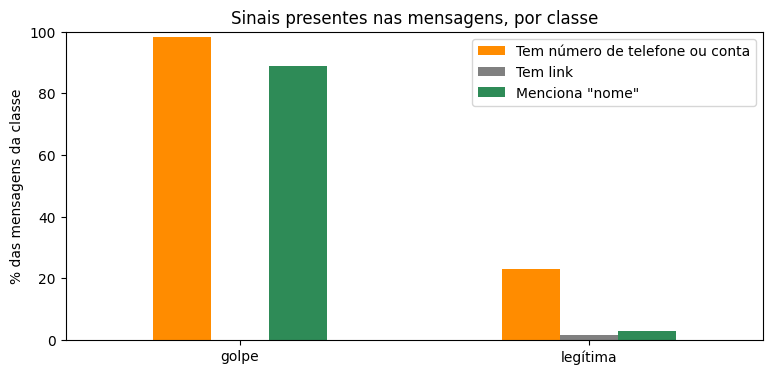

In [ ]:
# Sinais por classe (camada gold)
grupos = silver.groupby('classe')
sinais = pd.DataFrame({
    'mensagens': grupos['texto'].count(),
    'media_caracteres': grupos['tamanho_caracteres'].mean().round(1),
    'media_palavras': grupos['qtd_palavras'].mean().round(1),
    'pct_com_numero': (grupos['tem_numero'].mean() * 100).round(1),
    'pct_com_link': (grupos['tem_link'].mean() * 100).round(1),
    'pct_menciona_nome': (grupos['menciona_nome'].mean() * 100).round(1),
})
sinais.to_csv(pasta_dados + '/gold/sinais_por_classe.csv')
display(sinais)

# Gráfico com o percentual de mensagens que têm cada sinal
percentuais = sinais[['pct_com_numero', 'pct_com_link', 'pct_menciona_nome']]
percentuais = percentuais.rename(columns={
    'pct_com_numero': 'Tem número de telefone ou conta',
    'pct_com_link': 'Tem link',
    'pct_menciona_nome': 'Menciona "nome"',
})
percentuais.plot(kind='bar', figsize=(9, 4), rot=0, color=['darkorange', 'gray', 'seagreen'])
plt.title('Sinais presentes nas mensagens, por classe')
plt.ylabel('% das mensagens da classe')
plt.xlabel('')
plt.ylim(0, 100)
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


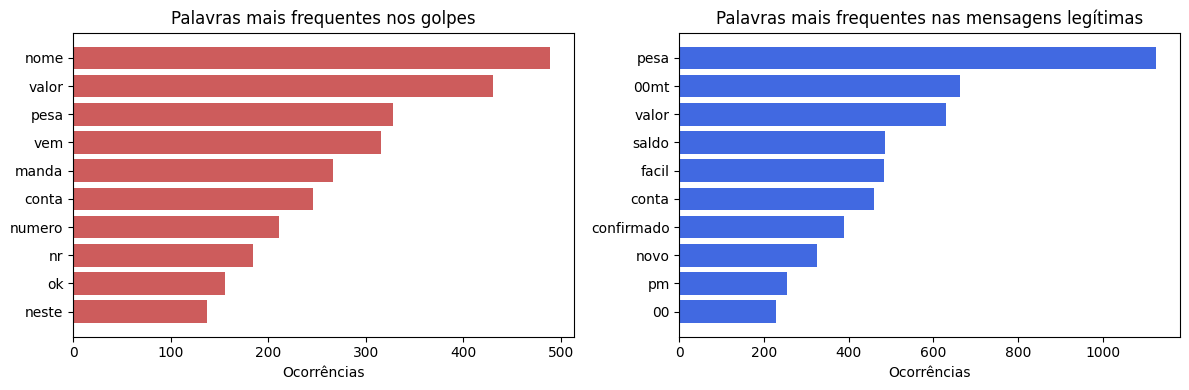

In [ ]:
# Palavras comuns do português, mais o marcador da anonimização
nltk.download('stopwords')
palavras_comuns = stopwords.words('portuguese') + ['num_oculto']

def palavras_mais_frequentes(mensagens, quantidade):
    # Conta quantas vezes cada palavra aparece no conjunto de mensagens
    contador = CountVectorizer(stop_words=palavras_comuns)
    matriz = contador.fit_transform(mensagens)
    totais = np.array(matriz.sum(axis=0))[0]

    # Junta cada palavra com o seu total e pega as mais frequentes
    frequencia = pd.Series(totais, index=contador.get_feature_names_out())
    frequencia = frequencia.sort_values(ascending=False)
    return frequencia.head(quantidade)

top_golpe = palavras_mais_frequentes(silver[silver['classe'] == 'golpe']['texto'], 10)
top_legitima = palavras_mais_frequentes(silver[silver['classe'] == 'legítima']['texto'], 10)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].barh(top_golpe.index, top_golpe.values, color='indianred')
axs[0].invert_yaxis()   # deixa a palavra mais frequente no topo
axs[0].set_title('Palavras mais frequentes nos golpes')
axs[0].set_xlabel('Ocorrências')

axs[1].barh(top_legitima.index, top_legitima.values, color='royalblue')
axs[1].invert_yaxis()
axs[1].set_title('Palavras mais frequentes nas mensagens legítimas')
axs[1].set_xlabel('Ocorrências')

plt.tight_layout()
plt.show()

**Discussão da P1.** Os golpes da base seguem quase sempre o mesmo roteiro: "manda o valor neste número, vem em nome de fulano". O golpista finge ser um conhecido e pede que a transferência vá para outra conta. Isso aparece nas palavras mais frequentes ("nome", "valor", "manda", "vem", "número") e na tabela de sinais, em que a maioria dos golpes tem número de telefone ou conta e menciona a palavra "nome".

As mensagens legítimas são, em boa parte, confirmações automáticas de transação ("confirmado", "saldo", "novo", valores em meticais). Parte delas também tem números, então esse sinal sozinho não separa as classes. Links quase não aparecem nos golpes desta base, diferente do golpe comum no Brasil, que costuma levar a um site falso.

Para a empresa, o sinal mais útil é a combinação de pedido de transferência com um número e o nome de outra pessoa.

### 7.2 P2. Qual modelo deixa passar menos golpes, e quantos alarmes falsos cada um gera?

Foram comparados dois modelos. A árvore de decisão é o classificador visto em aula e serve de base de comparação. É fácil de explicar, porque funciona como uma sequência de perguntas sobre as palavras. O Naive Bayes é um modelo clássico de filtros de spam, funciona bem com contagem de palavras e calcula a probabilidade de golpe, que a regra de decisão da P3 usa.

A silver é dividida em 70% para treino e 30% para teste, com a mesma proporção de golpes nos dois conjuntos.

In [ ]:
# Divisão em treino (70%) e teste (30%), mantendo a proporção entre as classes
train_df, test_df = train_test_split(silver, test_size=0.3, random_state=42, stratify=silver['classe'])

X_train = train_df['texto']
y_train = train_df['classe']
X_test = test_df['texto']
y_test = test_df['classe']

# Conta as palavras de cada mensagem (strip_accents junta 'número' e 'numero')
vectorizer = CountVectorizer(strip_accents='unicode')
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Treinamento e previsão dos dois modelos
arvore = DecisionTreeClassifier(random_state=42)
arvore.fit(X_train_vectorized, y_train)
y_pred_arvore = arvore.predict(X_test_vectorized)

naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_vectorized, y_train)
y_pred_nb = naive_bayes.predict(X_test_vectorized)

print('Mensagens de treino:', len(train_df), '| de teste:', len(test_df))
print('Ordem das classes nos modelos:', naive_bayes.classes_)

Mensagens de treino: 1787 | de teste: 766
Ordem das classes nos modelos: ['golpe' 'legítima']


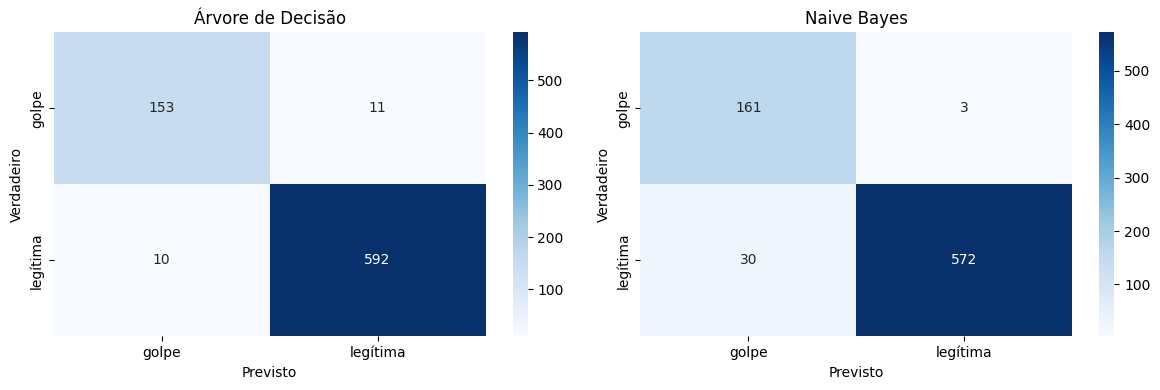

Árvore de Decisão
              precision    recall  f1-score   support

       golpe       0.94      0.93      0.94       164
    legítima       0.98      0.98      0.98       602

    accuracy                           0.97       766
   macro avg       0.96      0.96      0.96       766
weighted avg       0.97      0.97      0.97       766

Naive Bayes
              precision    recall  f1-score   support

       golpe       0.84      0.98      0.91       164
    legítima       0.99      0.95      0.97       602

    accuracy                           0.96       766
   macro avg       0.92      0.97      0.94       766
weighted avg       0.96      0.96      0.96       766



In [ ]:
# Matrizes de confusão (linhas = classe real, colunas = classe prevista)
classes = ['golpe', 'legítima']
matriz_arvore = confusion_matrix(y_test, y_pred_arvore, labels=classes)
matriz_nb = confusion_matrix(y_test, y_pred_nb, labels=classes)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(matriz_arvore, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axs[0])
axs[0].set_title('Árvore de Decisão')
axs[0].set_xlabel('Previsto')
axs[0].set_ylabel('Verdadeiro')

sns.heatmap(matriz_nb, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axs[1])
axs[1].set_title('Naive Bayes')
axs[1].set_xlabel('Previsto')
axs[1].set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()

print('Árvore de Decisão')
print(classification_report(y_test, y_pred_arvore))
print('Naive Bayes')
print(classification_report(y_test, y_pred_nb))

          Árvore de Decisão  Naive Bayes
Precisão              0.939        0.843
Recall                0.933        0.982
F1-score              0.936        0.907

Golpes não detectados: árvore = 11 | Naive Bayes = 3
Legítimas marcadas como golpe: árvore = 10 | Naive Bayes = 30


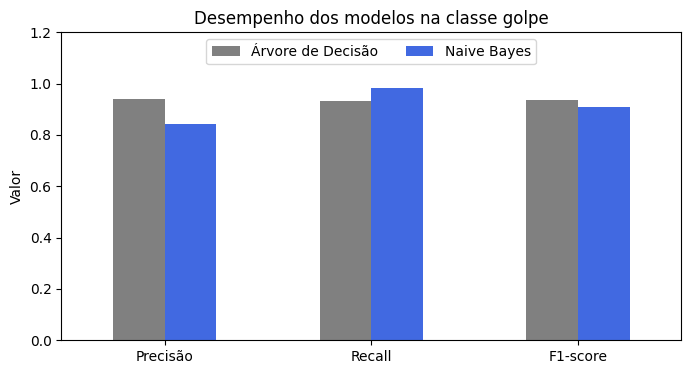

In [ ]:
# Métricas da classe golpe de cada modelo
resultados = pd.DataFrame({
    'Árvore de Decisão': [
        precision_score(y_test, y_pred_arvore, pos_label='golpe'),
        recall_score(y_test, y_pred_arvore, pos_label='golpe'),
        f1_score(y_test, y_pred_arvore, pos_label='golpe'),
    ],
    'Naive Bayes': [
        precision_score(y_test, y_pred_nb, pos_label='golpe'),
        recall_score(y_test, y_pred_nb, pos_label='golpe'),
        f1_score(y_test, y_pred_nb, pos_label='golpe'),
    ],
}, index=['Precisão', 'Recall', 'F1-score'])

print(resultados.round(3))
print()
print('Golpes não detectados: árvore =', matriz_arvore[0][1], '| Naive Bayes =', matriz_nb[0][1])
print('Legítimas marcadas como golpe: árvore =', matriz_arvore[1][0], '| Naive Bayes =', matriz_nb[1][0])

resultados.plot(kind='bar', figsize=(8, 4), color=['gray', 'royalblue'], rot=0)
plt.title('Desempenho dos modelos na classe golpe')
plt.ylabel('Valor')
plt.ylim(0, 1.2)
plt.legend(loc='upper center', ncol=2)
plt.show()

**Discussão da P2.** As duas matrizes mostram erros de tipos diferentes. O que interessa aqui é a primeira linha de cada matriz, a dos golpes reais: deixar passar um golpe é o erro mais grave, enquanto marcar uma mensagem legítima como golpe só atrasa a entrega.

Por isso o critério de escolha é o recall da classe golpe, e não a acurácia. O Naive Bayes tem o recall mais alto e deixa passar menos golpes. Em troca, pode marcar mais mensagens legítimas como golpe, o que aparece na segunda linha das matrizes. Para segurança, é uma troca aceitável, e o Naive Bayes foi o modelo escolhido.

### 7.3 P3. Com a regra de decisão, quantos golpes são bloqueados e quanto trabalho de revisão sobra para a TI?

O sistema usa o Naive Bayes também porque ele devolve uma probabilidade de golpe entre 0% e 100%. A árvore de decisão, treinada sem limite de profundidade, quase sempre devolve 0% ou 100%, e sem valores intermediários não existe faixa de revisão.

A regra funciona como um semáforo:

- risco de 70% ou mais: bloquear;
- risco entre 40% e 70%: encaminhar para revisão da equipe de TI;
- risco abaixo de 40%: liberar.

In [ ]:
# Limites da regra de decisão
limite_bloqueio = 0.70
limite_revisao = 0.40

def decidir_acao(risco):
    # Aplica a regra de decisão a partir do risco de golpe
    if risco >= limite_bloqueio:
        return 'BLOQUEAR'
    elif risco >= limite_revisao:
        return 'REVISAR'
    else:
        return 'LIBERAR'

# Risco de golpe de cada mensagem de teste (coluna 0 = golpe)
risco_teste = naive_bayes.predict_proba(X_test_vectorized)[:, 0]

acoes = []
for risco in risco_teste:
    acoes.append(decidir_acao(risco))

# Tabela de predições (camada gold)
predicoes = pd.DataFrame({
    'id_mensagem': test_df['id_mensagem'],
    'classe_real': y_test,
    'previsao_arvore': y_pred_arvore,
    'previsao_nb': y_pred_nb,
    'risco_golpe': risco_teste,
    'acao_recomendada': acoes,
})
predicoes.to_csv(pasta_dados + '/gold/predicoes.csv', index=False)

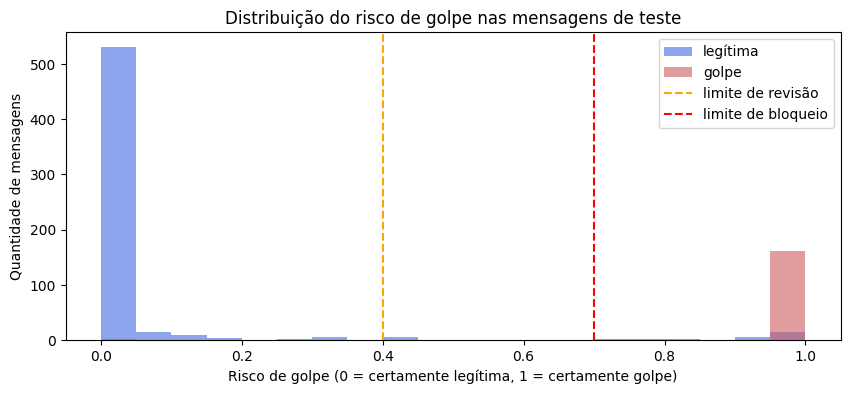

In [ ]:
# Histograma do risco, separado por classe, com os limites da regra
plt.figure(figsize=(10, 4))
plt.hist(predicoes[predicoes['classe_real'] == 'legítima']['risco_golpe'], bins=20, color='royalblue', alpha=0.6, label='legítima')
plt.hist(predicoes[predicoes['classe_real'] == 'golpe']['risco_golpe'], bins=20, color='indianred', alpha=0.6, label='golpe')
plt.axvline(limite_revisao, color='orange', linestyle='--', label='limite de revisão')
plt.axvline(limite_bloqueio, color='red', linestyle='--', label='limite de bloqueio')
plt.title('Distribuição do risco de golpe nas mensagens de teste')
plt.xlabel('Risco de golpe (0 = certamente legítima, 1 = certamente golpe)')
plt.ylabel('Quantidade de mensagens')
plt.legend()
plt.show()

classe_real       golpe  legítima
acao_recomendada                 
LIBERAR               3       566
REVISAR               0         9
BLOQUEAR            161        27


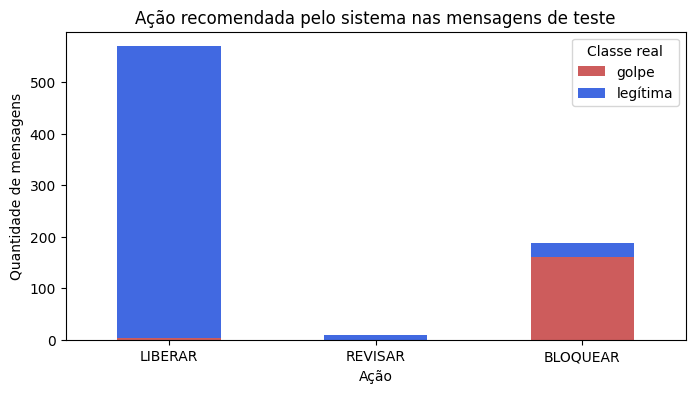

In [ ]:
# Quantidade de mensagens de cada classe em cada ação
tabela_acoes = pd.crosstab(predicoes['acao_recomendada'], predicoes['classe_real'])
tabela_acoes = tabela_acoes.reindex(['LIBERAR', 'REVISAR', 'BLOQUEAR'], fill_value=0)
print(tabela_acoes)

tabela_acoes.plot(kind='bar', stacked=True, figsize=(8, 4), color=['indianred', 'royalblue'], rot=0)
plt.title('Ação recomendada pelo sistema nas mensagens de teste')
plt.xlabel('Ação')
plt.ylabel('Quantidade de mensagens')
plt.legend(title='Classe real')
plt.show()

In [ ]:
# Teste da hipótese do MVP
total_golpes = (predicoes['classe_real'] == 'golpe').sum()
total_legitimas = (predicoes['classe_real'] == 'legítima').sum()

pct_golpes_bloqueados = 100 * tabela_acoes.loc['BLOQUEAR', 'golpe'] / total_golpes
pct_legitimas_bloqueadas = 100 * tabela_acoes.loc['BLOQUEAR', 'legítima'] / total_legitimas
pct_revisao = 100 * tabela_acoes.loc['REVISAR'].sum() / len(predicoes)

metas = pd.DataFrame({
    'meta': ['pelo menos 90%', 'no máximo 5%', 'no máximo 10%'],
    'resultado (%)': [round(pct_golpes_bloqueados, 1), round(pct_legitimas_bloqueadas, 1), round(pct_revisao, 1)],
    'atendida': [pct_golpes_bloqueados >= 90, pct_legitimas_bloqueadas <= 5, pct_revisao <= 10],
}, index=['Golpes bloqueados', 'Legítimas bloqueadas', 'Mensagens enviadas para revisão'])
display(metas)

print()
if metas['atendida'].all():
    print('Hipótese confirmada: as três metas foram atendidas.')
else:
    print('Hipótese não confirmada: pelo menos uma meta não foi atendida.')

,meta,resultado (%),atendida
Golpes bloqueados,pelo menos 90%,98.2,True
Legítimas bloqueadas,no máximo 5%,4.5,True
Mensagens enviadas para revisão,no máximo 10%,1.2,True



Hipótese confirmada: as três metas foram atendidas.


**Discussão da P3.** A tabela de metas responde diretamente à hipótese do MVP. O histograma ajuda a entender o resultado: o Naive Bayes dá riscos muito próximos de 0% ou de 100%, com poucas mensagens no meio. Por isso a faixa de revisão recebe poucas mensagens, o que reduz o trabalho da equipe de TI.

O lado ruim é que os erros acontecem com o modelo "confiante". As mensagens legítimas bloqueadas tiveram risco alto e não caíram na faixa de dúvida, onde uma pessoa poderia corrigir o erro.

### 7.4 P4. Como a escolha do limite de bloqueio muda o resultado?

,limite_bloqueio,golpes_bloqueados,golpes_nao_bloqueados,legitimas_bloqueadas
0,0.50,161,3,30
1,0.60,161,3,29
2,0.70,161,3,27
3,0.80,161,3,22
4,0.90,161,3,20
5,0.95,161,3,15
6,0.99,159,5,13


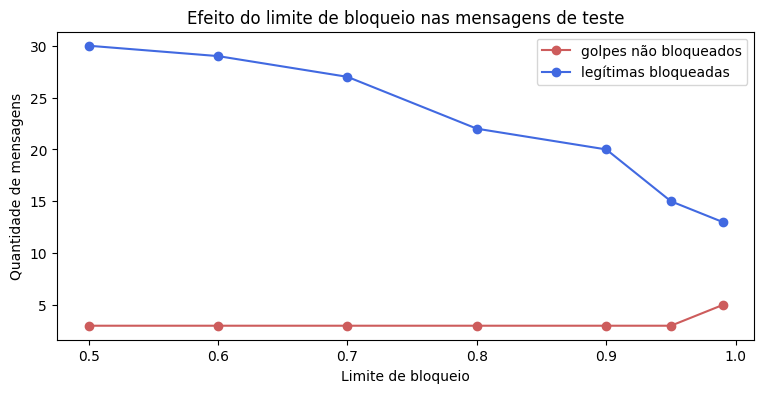

In [ ]:
# Simulação de diferentes limites de bloqueio (camada gold)
limites = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
linhas = []

for limite in limites:
    bloqueadas = predicoes[predicoes['risco_golpe'] >= limite]
    golpes_bloqueados = (bloqueadas['classe_real'] == 'golpe').sum()
    legitimas_bloqueadas = (bloqueadas['classe_real'] == 'legítima').sum()
    linhas.append({
        'limite_bloqueio': limite,
        'golpes_bloqueados': golpes_bloqueados,
        'golpes_nao_bloqueados': total_golpes - golpes_bloqueados,
        'legitimas_bloqueadas': legitimas_bloqueadas,
    })

simulacao = pd.DataFrame(linhas)
simulacao.to_csv(pasta_dados + '/gold/simulacao_limites.csv', index=False)
display(simulacao)

plt.figure(figsize=(9, 4))
plt.plot(simulacao['limite_bloqueio'], simulacao['golpes_nao_bloqueados'], marker='o', color='indianred', label='golpes não bloqueados')
plt.plot(simulacao['limite_bloqueio'], simulacao['legitimas_bloqueadas'], marker='o', color='royalblue', label='legítimas bloqueadas')
plt.title('Efeito do limite de bloqueio nas mensagens de teste')
plt.xlabel('Limite de bloqueio')
plt.ylabel('Quantidade de mensagens')
plt.legend()
plt.show()

**Discussão da P4.** Um limite mais alto bloqueia menos mensagens legítimas, mas deixa mais golpes sem bloqueio. Um limite mais baixo faz o contrário. Como os riscos calculados ficam concentrados nos extremos, as duas curvas mudam pouco em boa parte da faixa testada.

Para a empresa, isso quer dizer que a escolha exata do limite pesa menos do que a qualidade do modelo e dos dados de treino. O limite de 70% é um ponto de partida razoável, e pode ser ajustado conforme a equipe de TI acompanhar os erros.

### 7.5 P5. O modelo reconhece golpes comuns no Brasil?

A base não tem mensagens brasileiras, então o teste usa seis golpes escritos no estilo dos que circulam no Brasil. A última mensagem imita o golpe mais comum da base, mas em português do Brasil. Por ser uma amostra pequena e escrita à mão, o resultado é só um indicativo.

In [ ]:
def calcular_risco(mensagem):
    # Aplica a mesma anonimização da silver e calcula o risco de golpe
    mensagem = pd.Series([mensagem]).str.replace('[0-9]{7,}', 'NUM_OCULTO', regex=True)
    return naive_bayes.predict_proba(vectorizer.transform(mensagem))[0][0]

golpes_brasil = [
    'Seu Pix foi bloqueado. Clique no link para regularizar sua conta',
    'Correios: sua encomenda está retida. Pague a taxa de R$ 9,90 para liberar a entrega',
    'Oi mãe, troquei de número. Pode fazer um Pix para mim? Depois te devolvo',
    'Seu CPF está irregular. Regularize agora para evitar o bloqueio',
    'Parabéns! Você ganhou um prêmio. Confirme seus dados bancários',
    'Aquele valor manda neste número 61999990000, a conta está em nome de Maria Souza',
]

linhas = []
for mensagem in golpes_brasil:
    risco = calcular_risco(mensagem)
    linhas.append({'mensagem': mensagem, 'risco (%)': round(risco * 100, 1), 'acao': decidir_acao(risco)})

teste_brasil = pd.DataFrame(linhas)
display(teste_brasil)
print()
print('Golpes brasileiros bloqueados:', (teste_brasil['acao'] == 'BLOQUEAR').sum(), 'de', len(teste_brasil))

,mensagem,risco (%),acao
0,Seu Pix foi bloqueado. Clique no link para reg...,0.0,LIBERAR
1,Correios: sua encomenda está retida. Pague a t...,0.1,LIBERAR
2,"Oi mãe, troquei de número. Pode fazer um Pix p...",0.0,LIBERAR
3,Seu CPF está irregular. Regularize agora para ...,26.2,LIBERAR
4,Parabéns! Você ganhou um prêmio. Confirme seus...,0.1,LIBERAR
5,"Aquele valor manda neste número 61999990000, a...",100.0,BLOQUEAR



Golpes brasileiros bloqueados: 1 de 6


**Discussão da P5.** O modelo só reconhece as palavras que viu no treinamento. Golpes com vocabulário brasileiro, como "Pix", "CPF" e "Correios", não se parecem com nada da base e tendem a receber risco baixo. Já a última mensagem, que repete o roteiro dos golpes de Moçambique, é reconhecida mesmo escrita em português do Brasil.

A resposta à pergunta é que o modelo não deve ser usado no Brasil sem ser treinado com mensagens daqui.

## 8. Discussão geral

O resultado da hipótese está na seção 7.3. O ponto central do trabalho é a separação entre o modelo e a decisão. O modelo calcula um risco, e a regra de decisão, com limites que a empresa pode ajustar, transforma esse risco em uma ação. É isso que faz do projeto um sistema de suporte à decisão, e não só um classificador: nos casos de dúvida, a decisão fica com uma pessoa.

As respostas se completam:

- a P1 mostra que os golpes da base seguem um roteiro bem marcado;
- a P2 mostra que, por isso, um modelo simples como o Naive Bayes encontra quase todos eles;
- a P3 e a P4 mostram que o sistema bloqueia a maior parte dos golpes com pouco trabalho de revisão;
- a P5 mostra o limite de tudo isso: o modelo só reconhece o tipo de golpe que viu. Um sistema de suporte à decisão depende da base de dados que o alimenta.

## 9. Ética, licença e proteção de dados

**Licença.** A base MOZ-Smishing é distribuída sob a licença CreativeML OpenRAIL-M, conforme a página do conjunto no Hugging Face. Ela permite uso e redistribuição, com restrições de uso descritas no próprio texto. O arquivo não é redistribuído: o notebook baixa direto da fonte.

**Dados pessoais (LGPD).** As mensagens contêm números de telefone e nomes de pessoas. Por isso:

- os números são anonimizados antes da carga na silver (R8);
- nenhum texto original é exibido no notebook;
- a camada bronze, que guarda o arquivo original, fica só na pasta privada do Colab ou do Drive.

Os nomes continuam no texto, porque removê-los com segurança exigiria uma técnica de reconhecimento de nomes, fora do escopo do MVP.

## 10. Autoavaliação

**Perguntas respondidas.** As perguntas P1 a P4 foram respondidas com os dados da base. A P5 foi respondida só em parte, porque o teste usou seis mensagens escritas por mim, e não uma amostra real de golpes brasileiros.

**Limitações dos dados.**

- A base é de Moçambique, com vocabulário e tipos de golpe diferentes dos brasileiros.
- A base é pequena, com cerca de 2,5 mil mensagens, e não recebe atualizações.
- Os rótulos da fonte foram tomados como corretos.
- Os nomes de pessoas não foram anonimizados.

**O que eu faria diferente.**

- Executaria o pipeline em uma plataforma de dados na nuvem, como o Databricks, com as camadas gravadas como tabelas e a execução organizada em um job. Neste trabalho, o pipeline rodou no Google Colab e as camadas foram salvas como arquivos CSV.
- Procuraria formar uma base brasileira, mesmo pequena, para treinar ou pelo menos testar o modelo.
- Usaria validação cruzada em vez de uma única divisão entre treino e teste.

**Extensões para uso contínuo.**

- Coletar, com consentimento, as mensagens que os funcionários reportam como suspeitas, e retreinar o modelo periodicamente.
- Agendar a execução do pipeline.
- Criar um painel para a TI acompanhar as mensagens bloqueadas e revisadas.
- Integrar a regra ao serviço de mensagens da empresa.